In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

na = np.array

import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = sns.color_palette("viridis", as_cmap=True)
norm = mcolors.Normalize(vmin=1, vmax=50)
# Create a dummy ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar
import os
import sys

from burst_shape.folders import get_project_folder

sys.path.insert(0, os.path.join(get_project_folder(), "scripts", "6_other"))
from Fig_supp_helpers import (
    fit_rise_decay,
    fwhm,
    get_group_colors,
    gid_to_numbers,
    load_burst_matrix,
    load_df_bursts,
    load_df_cultures,
    load_spectral_embedding_npy,
    plot_burst_examples,
    plot_embeddings,
    savefig,
)

In [ ]:
# def get_group_colors(dataset):
#     match dataset:
#         case "inhibblock":
#             return get_inhibblock_colors()
#         case "wagenaar":
#             return get_wagenaar_colors()
#         case "kapucu":
#             return get_kapucu_colors()
#         case "mossink" | "mossink_KS" | "mossink_MELAS":
#             return get_mossink_colors()
#         case "hommersom":
#             return get_hommersom_colors()
#         case "hommersom_binary":
#             return get_hommersom_binary_colors()
#         case _:
#             return None


# def get_inhibblock_colors():
#     return {
#         "bic": "#e377c2",  #  "#ff7f0e",
#         "control": "#17becf",  # "#1f77b4",
#     }


# def get_wagenaar_colors():
#     set1_colors = sns.color_palette("Set1", 8).as_hex()
#     colors = {i + 1: set1_colors[i] for i in range(8)}
#     return colors


# def get_kapucu_colors():
#     return {
#         ("Rat", "MEA1"): "#03fcdf",
#         ("hPSC", "MEA1"): "#fc0303",
#         ("hPSC", "MEA2"): "#fc9d03",
#         "Rat": "#03fcdf",
#         "hPSC": "#fc9d03",
#     }


# def get_mossink_colors():
#     control_colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
#     melas_colors = plt.cm.Greens(np.linspace(0.4, 0.9, 3))
#     ks_colors = plt.cm.Reds(np.linspace(0.4, 0.9, 4))
#     label_color_dict = {}

#     def _rgba_to_hex(color):
#         return "#{:02x}{:02x}{:02x}".format(
#             int(color[0] * 255), int(color[1] * 255), int(color[2] * 255)
#         )

#     for i, color in enumerate(control_colors, start=1):
#         label = f"Control {i}"
#         label_color_dict[label] = _rgba_to_hex(color)
#     for i, color in enumerate(melas_colors, start=1):
#         label = f"MELAS {i}"
#         label_color_dict[label] = _rgba_to_hex(color)
#     for i, color in enumerate(ks_colors, start=1):
#         label = f"KS {i}"
#         label_color_dict[label] = _rgba_to_hex(color)

#     def _average_color(colors):
#         avg = np.mean(colors[:, :3], axis=0)  # exclude alpha channel if present
#         return _rgba_to_hex((*avg, 1.0))

#     label_color_dict["Control"] = _average_color(control_colors)
#     label_color_dict["MELAS"] = _average_color(melas_colors)
#     label_color_dict["KS"] = _average_color(ks_colors)
#     return label_color_dict


# def get_hommersom_colors():
#     # label_color_dict = {
#     #     "Control": "#0fff00",  # "#d62728",  # "#7f7f7f",
#     #     "CACNA1A": "#1A75A1",
#     #     "Other": "#DAA520",  # "#7f7f7f",
#     # }
#     label_color_dict = get_hommersom_binary_colors()
#     label_color_dict["Other"] = "#0fff00"
#     return label_color_dict


# def get_hommersom_binary_colors():
#     label_color_dict = {
#         "Control": "#7f7f7f",  # "#0fff00",  # "#d62728",
#         "CACNA1A": "#C87533",  # "#DAA520",  # "#1A75A1",
#     }
#     return label_color_dict

# Colorbar

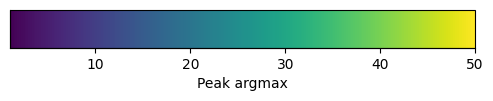

In [2]:
# Plot the colorbar
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

cbar = fig.colorbar(sm, cax=ax, orientation="horizontal")
cbar.set_label("Peak argmax")
sns.despine()

# plt.show()
# plt.savefig('figures/raw_oleg/bar.pdf')

# Subplot A Mossink

In [230]:
# Mossink example
burst_params = (
    "burst_dataset_mossink_maxISIstart_100_maxISIb_50_minBdur_10"
    "0_minIBI_500_n_bins_50_normalization_integral_min_length_30"
)
dd = load_burst_matrix(burst_params)
embedding_coordinates = load_spectral_embedding_npy(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_85"
)
df = load_df_bursts(burst_params)
cult_orig = load_df_cultures(burst_params)
cult_orig = cult_orig.reset_index()
labels = np.array([df.iloc[i].name[0] for i in range(len(df))])
subjects = np.array([df.iloc[i].name[1] for i in range(len(df))])
divs = np.array([df.iloc[i].name[2] for i in range(len(df))])
lab_div = np.array(
    [str(df.iloc[i].name[0]) + "_" + str(df.iloc[i].name[2]) for i in range(len(df))]
)
dff = pd.DataFrame(
    {
        "x0": embedding_coordinates[:, 0],
        "x1": embedding_coordinates[:, 1],
        "div": divs,
        "labels": labels,
        "subjects": subjects,
        "div_lab": lab_div,
    }
)
filt_dd = [gaussian_filter1d(d, sigma=1) for d in dd]
na = np.array
filt_dd = na(filt_dd)
df = df.reset_index()
df["x0"] = embedding_coordinates[:, 0]
df["x1"] = embedding_coordinates[:, 1]
df["labels"] = labels
df["div_lab"] = lab_div
df["subjects"] = subjects
df["argmax"] = np.argmax(filt_dd, 1)
widths = []
xs = np.arange(0, len(df.iloc[0]["burst"]))
for _i, k in df.iterrows():
    widths.append(fwhm(xs, k["burst"]))
df["fwhm"] = widths

from scipy.stats import kurtosis, skew


def bim_coeff(x):
    return (skew(x, bias=False) ** 2 + 1) / kurtosis(x, fisher=False, bias=False)


bims = []
rises = []
decays = []
# xs = np.arange(0,len(df.iloc[0]['burst']))
for _i, k in df.iterrows():
    bims.append(bim_coeff(k["burst"]))
    result = fit_rise_decay(np.arange(0, len(k["burst"])), k["burst"])
    rises.append(result["parameters"]["tau_rise"])
    decays.append(result["parameters"]["tau_decay"])
df["tau_rise"] = na(rises)
df["tau_decay"] = na(decays)

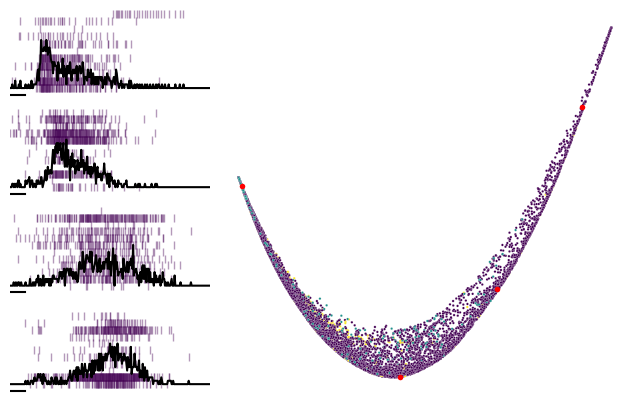

In [19]:
# keys = ['group','subject_id','well_idx']
# ns = [777,2150,7921,4894]
_ = plot_embeddings(
    df,
    cult_orig,
    [0, 2150, 7921, 4894],
    [],
    keys=["group", "subject_id", "well_idx"],
    x_window={"left": 2500, "extra": 2000},
    inset_offset=[0.185, 0.185],
    inset_on=True,
    sc_scale=2,
    color_by="group",
    cmap=cmap,
)
# plt.savefig('figures/raw_oleg/embedding_Mossink_full.pdf')

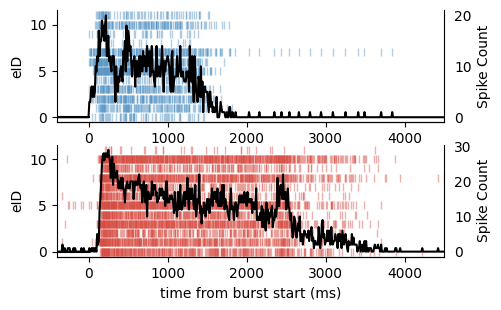

In [231]:
indc = np.where(df["group"] == "Control")[0][7000]  # 6000
indks = np.where(df["group"] == "KS")[0][680]  # 620, 622, 680

fig = plot_burst_examples(
    df,
    cult_orig,
    [indc, indks],
    keys=["group", "subject_id", "well_idx"],  # t_pre=400,t_post=4500,
    cmap=get_group_colors("mossink_KS"),
    t_pre=400,
    t_post=4500,
    color_by="group",
)
savefig(fig, "ExampleMossink", file_format=["svg"])

# Subplot B Hommersom

In [3]:
burst_params = (
    "burst_dataset_hommersom_binary_maxISIstart_20_maxISIb_20_minBdur_50_m"
    "inIBI_100_minSburst_100_n_bins_50_normalization_integral_min_length_30"
)
dd = load_burst_matrix(burst_params)
embedding_coordinates = load_spectral_embedding_npy(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_21"
)
df = load_df_bursts(burst_params)
cult_orig = load_df_cultures(burst_params)

labels = np.array([df.iloc[i].name[0] for i in range(len(df))])
divs = np.array([df.iloc[i].name[2] for i in range(len(df))])
lab_div = np.array(
    [str(df.iloc[i].name[0]) + "_" + str(df.iloc[i].name[2]) for i in range(len(df))]
)
dff = pd.DataFrame(
    {
        "x0": embedding_coordinates[:, 0],
        "x1": embedding_coordinates[:, 1],
        "div": divs,
        "labels": labels,
        "div_lab": lab_div,
    }
)

from scipy.ndimage import gaussian_filter1d

# smoothed_y = gaussian_filter1d(y, sigma=2)  # sigma controls smoothing amount
filt_dd = [gaussian_filter1d(d, sigma=1) for d in dd]
na = np.array
filt_dd = na(filt_dd)
cult_orig = cult_orig.reset_index()

df = df.reset_index()
#
df["x0"] = embedding_coordinates[:, 0]
df["x1"] = embedding_coordinates[:, 1]
df["labels"] = labels
df["div_lab"] = lab_div
# df['subjects'] = subjects
df["argmax"] = np.argmax(filt_dd, 1)
widths = []
xs = np.arange(0, len(df.iloc[0]["burst"]))
for _i, k in df.iterrows():
    widths.append(fwhm(xs, k["burst"]))
df["fwhm"] = widths


def bim_coeff(x):
    return (skew(x, bias=False) ** 2 + 1) / kurtosis(x, fisher=False, bias=False)


bims = []
rises = []
decays = []
# xs = np.arange(0,len(df.iloc[0]['burst']))
for _i, k in df.iterrows():
    bims.append(bim_coeff(k["burst"]))
    result = fit_rise_decay(np.arange(0, len(k["burst"])), k["burst"])
    rises.append(result["parameters"]["tau_rise"])
    decays.append(result["parameters"]["tau_decay"])
df["tau_rise"] = na(rises)
df["tau_decay"] = na(decays)

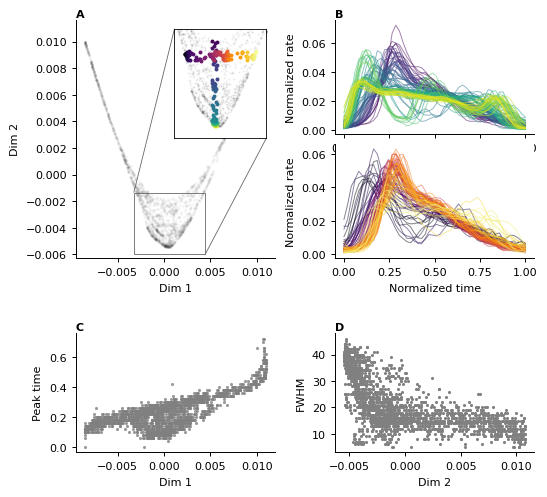

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from scipy.ndimage import gaussian_filter1d

# ---------------------------------------------------------------------
# Global figure settings
# ---------------------------------------------------------------------
MM_TO_INCH = 1 / 25.4
FIGSIZE = (256 / 2 * MM_TO_INCH, 130 * MM_TO_INCH)

plt.rcParams.update(
    {
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


# ---------------------------------------------------------------------
# Selection windows
# ---------------------------------------------------------------------
x0, y0 = 0.0001, -0.0025

dx1, dy1 = 0.0002, 0.005
mask1 = (
    (df["x0"] < x0 + dx1)
    & (df["x0"] > x0 - dx1)
    & (df["x1"] > y0 - dy1)
    & (df["x1"] < y0 + dy1)
)

ind = np.where(mask1)[0]
ind = ind[np.argsort(df["x1"].iloc[ind].to_numpy())]

colors = sns.color_palette("viridis_r", n_colors=max(len(ind), 1))


dx2, dy2 = 0.007, 0.0002
mask2 = (
    (df["x0"] < x0 + dx2)
    & (df["x0"] > x0 - dx2)
    & (df["x1"] > y0 - dy2)
    & (df["x1"] < y0 + dy2)
)

ind2 = np.where(mask2)[0]
ind2 = ind2[np.argsort(df["x0"].iloc[ind2].to_numpy())]

colors2 = sns.color_palette("inferno", n_colors=max(len(ind2), 1))


# ---------------------------------------------------------------------
# Figure layout: two columns
#
# Left column:
#   A: embedding
#   C: Dim 1 versus peak time
#
# Right column:
#   B: two burst-shape examples
#   D: Dim 2 versus FWHM
# ---------------------------------------------------------------------
fig = plt.figure(figsize=FIGSIZE)

outer = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    height_ratios=[2.0, 1.0],
    width_ratios=[1.0, 1.0],
    left=0.075,
    right=0.985,
    bottom=0.12,
    top=0.965,
    wspace=0.30,
    hspace=0.42,
)


# ---------------------------------------------------------------------
# A: spectral embedding with inset
# ---------------------------------------------------------------------
axA = fig.add_subplot(outer[0, 0])

axA.scatter(
    df["x0"], df["x1"], s=3, color="black", alpha=0.05, linewidths=0, rasterized=True
)

axA.set_xlabel("Dim 1")
axA.set_ylabel("Dim 2")
axA.set_title("A", loc="left", fontweight="bold", pad=2)

sns.despine(ax=axA)


# Determine inset limits safely
sel_x = np.concatenate([df["x0"].iloc[ind].to_numpy(), df["x0"].iloc[ind2].to_numpy()])

sel_y = np.concatenate([df["x1"].iloc[ind].to_numpy(), df["x1"].iloc[ind2].to_numpy()])

if len(sel_x) > 0:
    range_x = np.ptp(sel_x)
    range_y = np.ptp(sel_y)

    pad_x = 0.15 * range_x if range_x > 0 else 0.001
    pad_y = 0.15 * range_y if range_y > 0 else 0.001

    xlim_in = (sel_x.min() - pad_x, sel_x.max() + pad_x)
    ylim_in = (sel_y.min() - pad_y, sel_y.max() + pad_y)

    axins = inset_axes(axA, width="46%", height="46%", loc="upper right", borderpad=0.8)

    axins.scatter(
        df["x0"],
        df["x1"],
        s=2,
        color="black",
        alpha=0.08,
        linewidths=0,
        rasterized=True,
    )

    for color, i in zip(colors, ind, strict=False):
        axins.scatter(
            df["x0"].iloc[i], df["x1"].iloc[i], s=8, color=color, linewidths=0
        )

    for color, i in zip(colors2, ind2, strict=False):
        axins.scatter(
            df["x0"].iloc[i], df["x1"].iloc[i], s=8, color=color, linewidths=0
        )

    axins.set_xlim(xlim_in)
    axins.set_ylim(ylim_in)
    axins.set_xticks([])
    axins.set_yticks([])

    axins.tick_params(left=False, bottom=False)

    for spine in axins.spines.values():
        spine.set_linewidth(0.6)

    mark_inset(axA, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=0.6)


# ---------------------------------------------------------------------
# B: burst examples, with two vertically stacked axes
# ---------------------------------------------------------------------
burst_grid = gridspec.GridSpecFromSubplotSpec(
    nrows=2, ncols=1, subplot_spec=outer[0, 1], hspace=0.08
)

axb1 = fig.add_subplot(burst_grid[0, 0])
axb2 = fig.add_subplot(burst_grid[1, 0])


# Narrow Dim 1 / wide Dim 2 selection
for color, i in zip(colors[::-1], ind[::-1], strict=False):
    burst = np.asarray(df.iloc[i]["burst"])

    axb1.plot(
        np.linspace(0, 1, len(burst)),
        gaussian_filter1d(burst, sigma=1),
        color=color,
        alpha=0.5,
        linewidth=0.7,
    )

axb1.set_title("B", loc="left", fontweight="bold", pad=2)

# axb1.axis('off')
axb1.set_xlabel("")
axb1.set_ylabel("Normalized rate")


# Wide Dim 1 / narrow Dim 2 selection
for color, i in zip(colors2, ind2, strict=False):
    burst = np.asarray(df.iloc[i]["burst"])

    axb2.plot(
        np.linspace(0, 1, len(burst)),
        gaussian_filter1d(burst, sigma=1),
        color=color,
        alpha=0.5,
        linewidth=0.7,
    )

# axb2.axis('off')
axb2.set_xlabel("Normalized time")
axb2.set_ylabel("Normalized rate")


# Optional horizontal scale bar
if len(ind2) > 0:
    all_bursts = [np.asarray(df.iloc[i]["burst"]) for i in ind2]

    y_min = min(np.nanmin(burst) for burst in all_bursts)
    y_max = max(np.nanmax(burst) for burst in all_bursts)
    y_range = y_max - y_min

    scale_y = y_min - 0.06 * y_range

    # axb2.plot(
    #     [0, 50],
    #     [scale_y, scale_y],
    #     color='black',
    #     linewidth=1,
    #     clip_on=False
    # )
sns.despine(ax=axb1)
sns.despine(ax=axb2)


# ---------------------------------------------------------------------
# C: Dim 1 versus peak time
# ---------------------------------------------------------------------
df = df.copy()
df["peak_offset"] = df["argmax"] / 50

axC = fig.add_subplot(outer[1, 0])

axC.scatter(
    df["x0"],
    df["peak_offset"],
    marker="o",
    s=5,
    color="gray",
    alpha=0.8,
    linewidths=0,
    rasterized=False,
)

axC.set_xlabel("Dim 1")
axC.set_ylabel("Peak time")
axC.set_title("C", loc="left", fontweight="bold", pad=2)

sns.despine(ax=axC)


# ---------------------------------------------------------------------
# D: Dim 2 versus FWHM
# ---------------------------------------------------------------------
axD = fig.add_subplot(outer[1, 1])

axD.scatter(
    df["x1"],
    df["fwhm"],
    marker="o",
    s=5,
    color="gray",
    alpha=1,
    linewidths=0,
    rasterized=False,
)

axD.set_xlabel("Dim 2")
axD.set_ylabel("FWHM")
axD.set_title("D", loc="left", fontweight="bold", pad=2)

sns.despine(ax=axD)


# ---------------------------------------------------------------------
# Save at the exact requested dimensions
# ------------------------------------------------
# ---------------------
savefig(fig, "fig3_hommersom_composite", file_format=["pdf"])

# fig.savefig(
#     'figures/raw_oleg/fig3_hommersom_composite.pdf',
#     dpi=600
# )

plt.show()

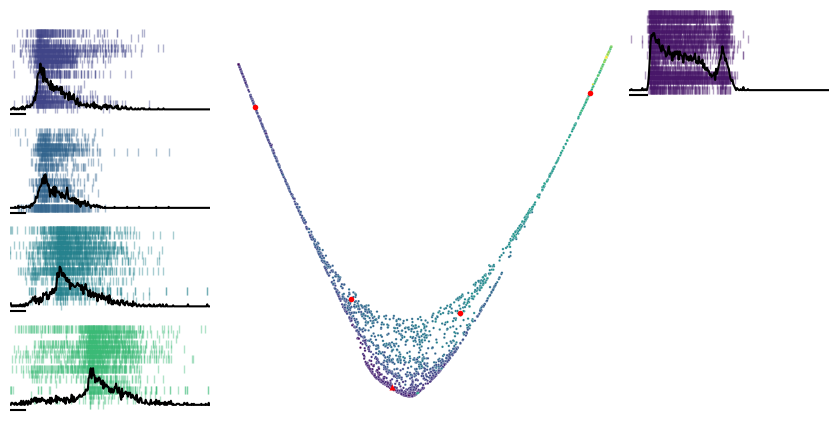

In [5]:
_ = plot_embeddings(
    df,
    cult_orig,
    [200, 1234, 2104, 2113],
    [985],
    keys=["batch", "well"],
    x_window={"left": 2500, "extra": 2000},
    inset_offset=[0.485, 0.185],
    inset_on=True,
    sc_scale=5,
    color_by="argmax",
    cmap=cmap,
)

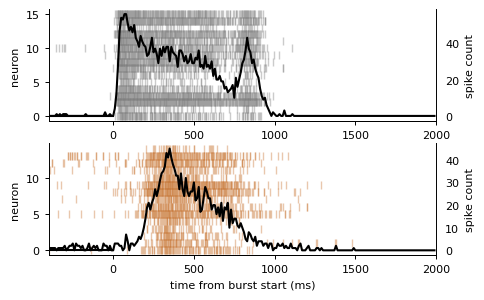

In [8]:
fig = plot_burst_examples(
    df,
    cult_orig,
    [985, 2004],
    keys=["batch", "well"],
    t_pre=400,
    t_post=2000,
    cmap=get_group_colors("hommersom"),
    color_by="group",
)
savefig(fig, "ExampleHommersom", file_format=["svg"])

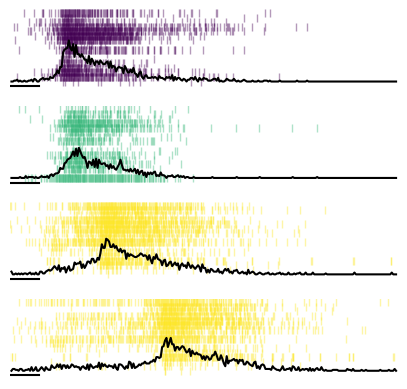

In [ ]:
def plot_burst_examples_simple(
    dff,
    cult_orig,
    ns,
    keys=None,
    x_window=1000,
    sc_scale=2,
    cmap=None,
    load_txt=False,
    color_by="argmax",
    txt_path="burst-clustering/data/extracted/",
):
    """
    Plot burst raster/histogram panels for a selection of indices `ns`,
    one row per index -- same data lookup and coloring as plot_embeddings,
    but without the embedding scatter or insets. See plot_embeddings for
    the meaning of each parameter.
    """
    if keys is None:
        keys = []
    keys_in = [k for k in keys if k in getattr(cult_orig, "keys", lambda: [])()]

    if (
        color_by not in dff.columns
        and keys_in
        and color_by in getattr(cult_orig, "keys", lambda: [])()
    ):
        lut = cult_orig[keys_in + [color_by]].drop_duplicates(subset=keys_in)
        dff = dff.merge(lut, on=keys_in, how="left").reset_index(drop=True)

    if cmap is None:
        cmap = plt.get_cmap("viridis")
    if color_by in dff:
        uniq = np.unique(dff[color_by])
        palette = [cmap(float(i) / max(len(uniq) - 1, 1)) for i in range(len(uniq))]
        arg_to_idx = {a: i for i, a in enumerate(sorted(uniq))}
    else:
        palette = None
        arg_to_idx = {}

    fig, axes = plt.subplots(len(ns), 1, figsize=(5, 1.2 * len(ns)), squeeze=False)

    for i, n in enumerate(ns):
        ax = axes[i, 0]

        values = [dff.iloc[n][k] for k in keys_in]
        i_burst = dff.iloc[n]["i_burst"]

        if len(keys_in) > 0:
            masks = [
                np.array(cult_orig[k] == v)
                for k, v in zip(keys_in, values, strict=False)
            ]
            mask = np.prod(np.vstack(masks), axis=0).astype(bool)
        else:
            mask = np.ones(len(cult_orig), dtype=bool)

        if load_txt:
            st, gid = np.loadtxt(txt_path + cult_orig[mask]["file_name"].item()).T
            xmin, xmax = dff.iloc[n]["start_orig"], dff.iloc[n]["end_orig"]
        else:
            st = list(cult_orig[mask]["times"].item())
            gid = list(cult_orig[mask]["gid"].item())
            xmin, xmax = cult_orig[mask]["burst_start_end"].item()[i_burst]

        sc, bins = np.histogram(
            na(st) * 1000, np.arange(xmin - 200, xmin + x_window, 10)
        )

        color_idx = arg_to_idx.get(dff[color_by].iloc[n], 0)
        ax.plot(
            na(st) * 1000,
            gid_to_numbers(na(gid)),
            "|",
            color=palette[color_idx] if palette is not None else "C0",
            alpha=0.4,
        )
        ax.plot(bins[1:], sc / sc_scale, "-", color="k")
        ax.set_xlim([xmin - 200, xmin + x_window])
        ax.plot([xmin - 200, xmin], [-1, -1], "k")
        ax.axis("off")

    return fig


fig = plot_burst_examples_simple(
    df,
    cult_orig,
    [200, 1234, 2104, 2113],
    keys=["batch", "well"],
    x_window=2500,
    sc_scale=5,
    color_by="labels",
)

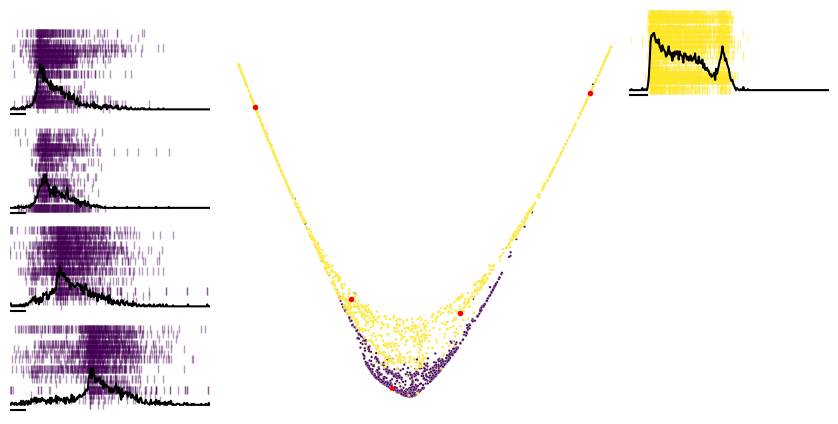

In [10]:
_ = plot_embeddings(
    df,
    cult_orig,
    [200, 1234, 2104, 2113],
    [985],
    keys=["batch", "well"],
    x_window={"left": 2500, "extra": 2000},
    inset_offset=[0.485, 0.185],
    inset_on=True,
    sc_scale=5,
    color_by="group",
    cmap=cmap,
)

# plt.savefig('figures/raw_oleg/embedding_Mossink_full.pdf')

# Subplot C Wagernaar

In [85]:
burst_params = (
    "burst_dataset_wagenaar_n_bins_50_normalization_integra"
    "l_min_length_30_min_firing_rate_3162_smoothing_kernel_4"
)
dd = load_burst_matrix(burst_params)
embedding_coordinates = load_spectral_embedding_npy(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_150"
)
df = load_df_bursts(burst_params)
cult_orig = load_df_cultures(burst_params)
cult_orig = cult_orig.reset_index()
labels = np.array([df.iloc[i].name[0] for i in range(len(df))])
divs = np.array([df.iloc[i].name[2] for i in range(len(df))])

culture = np.array(
    [str(df.iloc[i].name[0]) + "_" + str(df.iloc[i].name[1]) for i in range(len(df))]
)
lab_div = np.array(
    [str(df.iloc[i].name[0]) + "_" + str(df.iloc[i].name[2]) for i in range(len(df))]
)
filt_dd = [gaussian_filter1d(d, sigma=1) for d in dd]
na = np.array
filt_dd = na(filt_dd)
#                     'max_peak':np.argmax(filt_dd, axis=1)})
df = df.reset_index()
df["batch"] = labels
df["x0"] = embedding_coordinates[:, 0]
df["x1"] = embedding_coordinates[:, 1]

# df['div_lab'] = lab_div
# df['subjects'] = subjects
df["argmax"] = np.argmax(filt_dd, 1)
widths = []
xs = np.arange(0, len(df.iloc[0]["burst"]))
for _i, k in df.iterrows():
    widths.append(fwhm(xs, k["burst"]))
df["fwhm"] = widths


def bim_coeff(x):
    return (skew(x, bias=False) ** 2 + 1) / kurtosis(x, fisher=False, bias=False)


bims = []
rises = []
decays = []
# xs = np.arange(0,len(df.iloc[0]['burst']))
for _i, k in df.iterrows():
    bims.append(bim_coeff(k["burst"]))
    result = fit_rise_decay(np.arange(0, len(k["burst"])), k["burst"])
    rises.append(result["parameters"]["tau_rise"])
    decays.append(result["parameters"]["tau_decay"])
df["tau_rise"] = na(rises)
df["tau_decay"] = na(decays)

KeyError: 'culture'

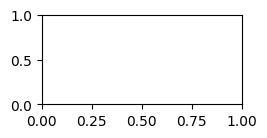

In [76]:
ns = [1, 270, 262, 570]
_ = plot_embeddings(
    df,
    cult_orig,
    [244, 3877, 11905, 6695],
    [],
    keys=["batch", "culture", "day"],
    x_window={"left": 1000, "extra": 2000},
    inset_offset=[0.185, 0.185],
    inset_on=True,
    cmap=cmap,
    dataset="wagenaar",
)
# plt.savefig('figures/raw_oleg/embedding_bic_full.pdf')

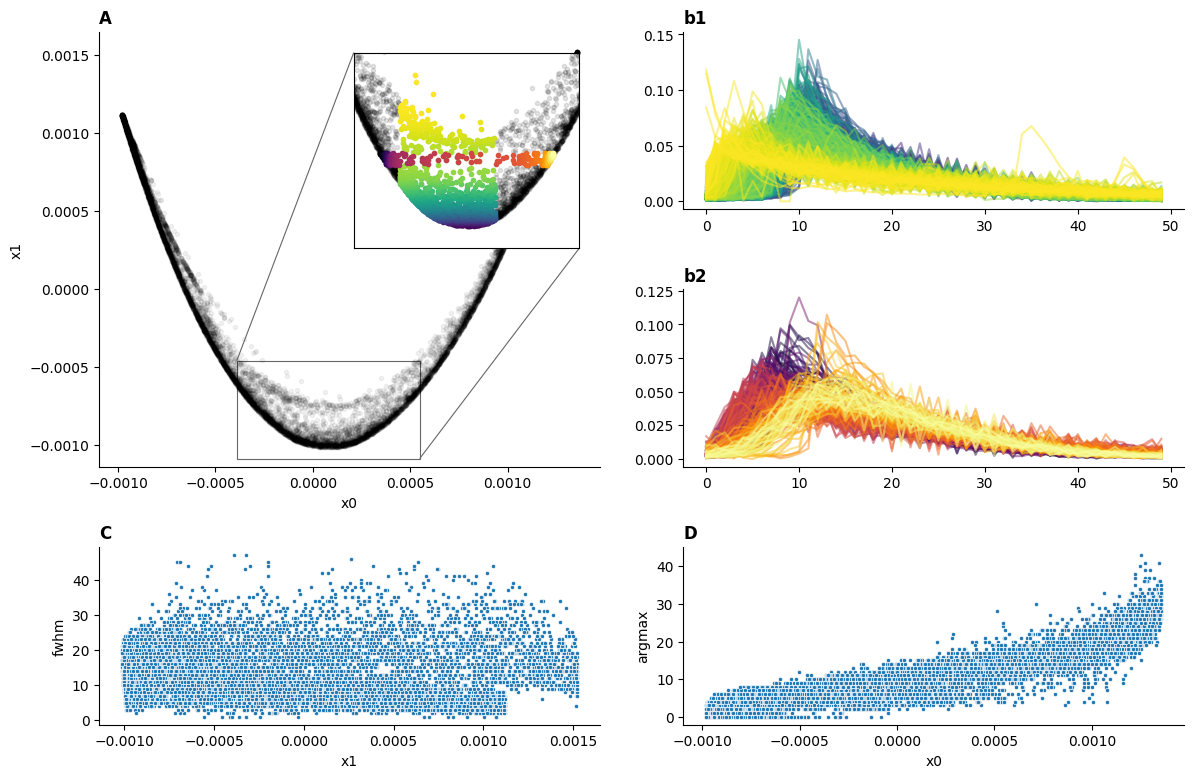

In [77]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- selection windows (same criteria as the exploratory cell above) ---
x0, y0 = 0.000, -0.0008

dx1, dy1 = 0.0002, 0.005
ind = np.where(
    (df["x0"] < x0 + dx1)
    * (df["x0"] > x0 - dx1)
    * (df["x1"] > y0 - dy1)
    * (df["x1"] < y0 + dy1)
)[0]
ind = ind[np.argsort(df["x1"][ind])]
colors = sns.color_palette("viridis", n_colors=len(ind))

dx2, dy2 = 0.007, 0.00002
ind2 = np.where(
    (df["x0"] < x0 + dx2)
    * (df["x0"] > x0 - dx2)
    * (df["x1"] > y0 - dy2)
    * (df["x1"] < y0 + dy2)
)[0]
ind2 = ind2[np.argsort(df["x0"][ind2])]
colors2 = sns.color_palette("inferno", n_colors=len(ind2))

fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.4, hspace=0.45)

# --- A: big scatter with zoomed inset on the example region ---
axA = fig.add_subplot(gs[0:2, 0:2])
axA.plot(df["x0"], df["x1"], ".k", alpha=0.05)
# for ii, i in enumerate(ind):
#     axA.plot(df['x0'][i], df['x1'][i], '.', color=colors[ii])
# for ii, i in enumerate(ind2):
#     axA.plot(df['x0'][i], df['x1'][i], '.', color=colors2[ii])
axA.set_xlabel("x0")
axA.set_ylabel("x1")
axA.set_title("A", loc="left", fontweight="bold")
sns.despine(ax=axA)

sel_x = np.concatenate([df["x0"].values[ind], df["x0"].values[ind2]])
sel_y = np.concatenate([df["x1"].values[ind], df["x1"].values[ind2]])
pad_x = (sel_x.max() - sel_x.min()) * 0.15
pad_y = (sel_y.max() - sel_y.min()) * 0.15
xlim_in = (sel_x.min() - pad_x, sel_x.max() + pad_x)
ylim_in = (sel_y.min() - pad_y, sel_y.max() + pad_y)

axins = inset_axes(axA, width="45%", height="45%", loc="upper right", borderpad=1.5)
axins.plot(df["x0"], df["x1"], ".k", alpha=0.1)
for ii, i in enumerate(ind):
    axins.plot(df["x0"][i], df["x1"][i], ".", color=colors[ii])
for ii, i in enumerate(ind2):
    axins.plot(df["x0"][i], df["x1"][i], ".", color=colors2[ii])
axins.set_xlim(xlim_in)
axins.set_ylim(ylim_in)
axins.set_xticks([])
axins.set_yticks([])
mark_inset(axA, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=0.8)

# --- b1: example bursts from the narrow-x0/wide-x1 band (colors = viridis) ---
axb1 = fig.add_subplot(gs[0, 2:4])
for ii, i in enumerate(ind):
    axb1.plot(df.iloc[i]["burst"], color=colors[ii], alpha=0.5)
axb1.set_title("b1", loc="left", fontweight="bold")
sns.despine(ax=axb1)

# --- b2: example bursts from the wide-x0/narrow-x1 band (colors = inferno) ---
axb2 = fig.add_subplot(gs[1, 2:4])
for ii, i in enumerate(ind2[:]):
    axb2.plot(df.iloc[i]["burst"], color=colors2[ii], alpha=0.5)
axb2.set_title("b2", loc="left", fontweight="bold")
sns.despine(ax=axb2)

# --- C: x1 vs fwhm ---
axC = fig.add_subplot(gs[2, 0:2])
sns.scatterplot(x="x1", y="fwhm", data=df, marker=".", ax=axC)
axC.set_title("C", loc="left", fontweight="bold")
sns.despine(ax=axC)

# --- D: x0 vs argmax ---
axD = fig.add_subplot(gs[2, 2:4])
sns.scatterplot(x="x0", y="argmax", data=df, marker=".", ax=axD)
axD.set_title("D", loc="left", fontweight="bold")
sns.despine(ax=axD)

# plt.savefig('figures/raw_oleg/fig3_hommersom_composite.pdf')

# Subplot D BIC 

In [86]:
# BIC Examples
# Examples embedding
burst_params = (
    "burst_dataset_inhibblock_maxISIstart_20_maxISIb_20_minBdur_50_minI"
    "BI_100_minSburst_100_n_bins_50_normalization_integral_min_length_30"
)
dd = load_burst_matrix(burst_params)
embedding_coordinates = load_spectral_embedding_npy(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_85"
)
df = load_df_bursts(burst_params)
cult_orig = load_df_cultures(burst_params)
cult_orig = cult_orig.reset_index()

labels = np.array([df.iloc[i].name[0] for i in range(len(df))])
divs = np.array([df.iloc[i].name[1] for i in range(len(df))])
lab_div = np.array(
    [str(df.iloc[i].name[0]) + "_" + str(df.iloc[i].name[1]) for i in range(len(df))]
)
filt_dd = [gaussian_filter1d(d, sigma=1) for d in dd]
na = np.array
filt_dd = na(filt_dd)
df = df.reset_index()

df["x0"] = embedding_coordinates[:, 0]
df["x1"] = embedding_coordinates[:, 1]
df["labels"] = labels
df["div_lab"] = lab_div

df["argmax"] = np.argmax(filt_dd, 1)
widths = []
xs = np.arange(0, len(df.iloc[0]["burst"]))
for _i, k in df.iterrows():
    widths.append(fwhm(xs, k["burst"]))
df["fwhm"] = widths


def bim_coeff(x):
    return (skew(x, bias=False) ** 2 + 1) / kurtosis(x, fisher=False, bias=False)


bims = []
rises = []
decays = []
# xs = np.arange(0,len(df.iloc[0]['burst']))
for _i, k in df.iterrows():
    bims.append(bim_coeff(k["burst"]))
    result = fit_rise_decay(np.arange(0, len(k["burst"])), k["burst"])
    rises.append(result["parameters"]["tau_rise"])
    decays.append(result["parameters"]["tau_decay"])
df["tau_rise"] = na(rises)
df["tau_decay"] = na(decays)

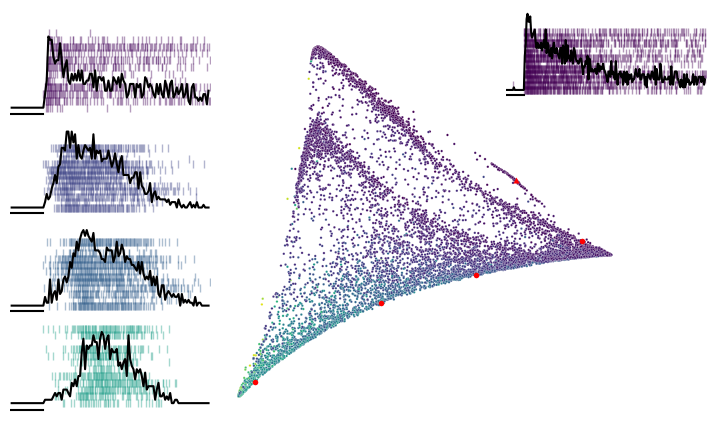

In [87]:
_ = plot_embeddings(
    df,
    cult_orig,
    [1, 270, 262, 570],
    [6014],
    keys=["drug_label", "div", "well_idx", "burst_n"],
    x_window={"left": 1000, "extra": 2000},
    inset_offset=[0.185, 0.185],
    inset_on=True,
    cmap=cmap,
)
# plt.savefig('figures/raw_oleg/embedding_bic_full.pdf')

In [93]:
df

,drug_label,div,well_idx,i_burst,start_orig,end_orig,start_extend,end_extend,time_orig,time_extend,...,integral,firing_rate,x0,x1,labels,div_lab,argmax,fwhm,tau_rise,tau_decay
0,control,18,0,0,7294.6,8619.2,7294.6,8619.2,1324.6,1324.6,...,33104.333384,662.086668,0.001490,0.000137,control,control_18,1,10,NaN,16.357408
1,control,18,0,1,14225.5,15607.65,14225.5,15607.65,1382.15,1382.15,...,29736.280433,594.725609,0.001847,-0.000093,control,control_18,1,10,NaN,12.953478
2,control,18,0,2,23218.2,24763.5,23218.2,24763.5,1545.3,1545.3,...,29638.257943,592.765159,0.001941,-0.000154,control,control_18,1,3,NaN,12.828235
3,control,18,0,3,31921.4,33513.6,31921.4,33513.6,1592.2,1592.2,...,29675.920111,593.518402,0.002024,-0.000219,control,control_18,0,8,NaN,23.444713
4,control,18,0,4,36188.65,37440.2,36188.65,37440.2,1251.55,1251.55,...,30122.647917,602.452958,0.001724,-0.000011,control,control_18,2,11,NaN,14.900454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8566,bic,17,9,94,1139902.6,1141215.2,1139902.6,1141215.2,1312.6,1312.6,...,74965.716898,1499.314338,0.000211,-0.000358,bic,bic_17,6,35,3.479463,30.622093
8567,bic,17,9,95,1152541.15,1154657.85,1152541.15,1154657.85,2116.7,2116.7,...,80904.237729,1618.084755,0.000165,0.000239,bic,bic_17,1,38,NaN,4799.999980
8568,bic,17,9,96,1165118.1,1168401.2,1165118.1,1168401.2,3283.1,3283.1,...,78142.609119,1562.852182,-0.000571,0.002198,bic,bic_17,0,44,NaN,22.485907
8569,bic,17,9,97,1186138.55,1188580.5,1186138.55,1188580.5,2441.95,2441.95,...,83642.171216,1672.843424,-0.000515,0.000889,bic,bic_17,0,39,NaN,4799.999981


In [149]:
indc = np.where(df["drug_label"] == "control")[0][200]  # 6000
indks = np.where(df["drug_label"] == "bic")[0][202]  # 620, 622

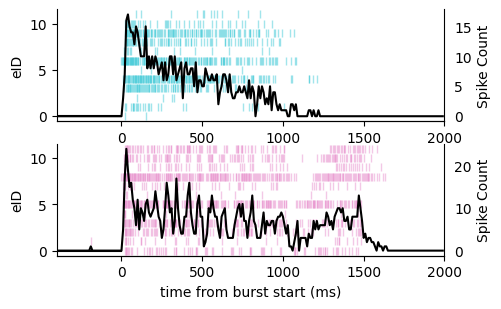

In [152]:
fig = plot_burst_examples(
    df,
    cult_orig,
    [indc, indks],
    keys=["drug_label", "div", "well_idx", "burst_n"],
    t_pre=400,
    t_post=2000,
    cmap=get_group_colors("inhibblock"),
    color_by="drug_label",
)
savefig(fig, "ExampleInhBlock", file_format=["svg"])

In [ ]:
_ = plot_embeddings(
    df,
    cult_orig,
    [1, 270, 262, 570],
    [1808, 7805],
    keys=["drug_label", "div", "well_idx", "burst_n"],
    x_window={"left": 1000, "extra": 2000},
    inset_offset=[0.185, 0.185],
    inset_on=True,
    cmap=cmap,
)
# plt.savefig('figures/raw_oleg/embedding_bic_full.pdf')